# N1 · 扩散动作头解决多峰 (vs 回归取平均)

> 配套 11.3-L1/L2 · 玩具: 绕障碍导航, 上绕/下绕都行 (双峰)。
> 训扩散动作头 + 连续回归头, 在障碍前采样动作:
> **扩散是双峰 (上/下), 回归塌成中间一点 (直冲障碍)**。这是 diffusion policy 的核心价值。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import diffusion_policy as dp
import numpy as np, torch
print('环境: 绕障碍导航, 障碍中心', dp.OBST_C, '半径', dp.OBST_R)

环境: 绕障碍导航, 障碍中心 [0. 0.] 半径 0.35


## 1. 双峰专家 demo: 一半上绕、一半下绕

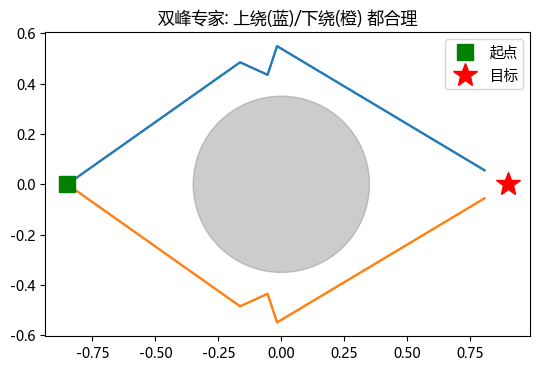

→ 同一起点, 两个同样合理的动作 (上/下绕) = 多峰动作分布。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import numpy as np
# 画几条专家轨迹 (上绕/下绕)
fig, ax = plt.subplots(figsize=(5.5,5))
for i in range(6):
    side = 1.0 if i%2==0 else -1.0
    pos = np.array([dp.START_X, 0.0], np.float32); tr=[pos.copy()]
    for _ in range(dp.MAX_T):
        tgt = dp._expert_target(pos, side); d=tgt-pos; n=np.linalg.norm(d)
        a = d/n if n>1e-6 else np.zeros(2); pos = pos + a*dp.STEP; tr.append(pos.copy())
        if dp.reached(pos): break
    tr=np.array(tr); ax.plot(tr[:,0],tr[:,1],'-',alpha=0.7,color='C0' if side>0 else 'C1')
circ = plt.Circle((dp.OBST_C[0], dp.OBST_C[1]), dp.OBST_R, color='gray', alpha=0.4)
ax.add_patch(circ)
ax.plot(dp.START_X,0,'gs',ms=12,label='起点'); ax.plot(*dp.GOAL,'r*',ms=18,label='目标')
ax.legend(); ax.set_title('双峰专家: 上绕(蓝)/下绕(橙) 都合理'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print('→ 同一起点, 两个同样合理的动作 (上/下绕) = 多峰动作分布。')

## 2. 训扩散动作头 + 连续回归头

In [3]:
torch.manual_seed(0)
S, A = dp.make_obstacle_demos(n=400, chunk=1, seed=0)
print(f'双峰专家 demo: {len(S)} 个 (state, action) 对')
diff = dp.build_diffusion_policy(chunk=1)
_, sched = dp.train_diffusion_policy(diff, S, A, epochs=800)
reg = dp.build_regression(chunk=1); dp.train_regression(reg, S, A, epochs=800)
print('扩散动作头 + 回归头 训练完毕')

双峰专家 demo: 6608 个 (state, action) 对


扩散动作头 + 回归头 训练完毕


## 3. 关键对比: 障碍前的动作分布 (扩散双峰 vs 回归取平均)

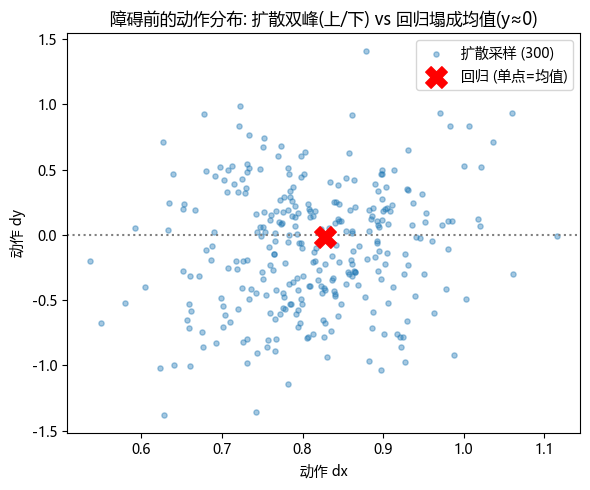

扩散采样: 朝上 94, 朝下 137 (双峰!); 回归动作 dy=-0.02 (≈0=取平均, 正对障碍)
→ 回归取均值 = 既不上也不下 = 直冲障碍 (多峰死穴); 扩散采样到某一峰 → 能绕开。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
st = np.array([dp.START_X, 0.0], np.float32)
acts = np.array([dp.sample_action(diff, st, sched, seed=k)[0] for k in range(300)])
reg_a = reg(torch.tensor(st[None])).detach().numpy()[0]
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(acts[:,0], acts[:,1], s=14, alpha=0.4, color='C0', label='扩散采样 (300)')
ax.scatter([reg_a[0]],[reg_a[1]], s=240, marker='X', color='red', label='回归 (单点=均值)', zorder=5)
ax.axhline(0, ls=':', c='gray')
ax.set_xlabel('动作 dx'); ax.set_ylabel('动作 dy')
ax.set_title('障碍前的动作分布: 扩散双峰(上/下) vs 回归塌成均值(y≈0)'); ax.legend()
plt.tight_layout(); plt.show()
up=(acts[:,1]>0.15).sum(); dn=(acts[:,1]<-0.15).sum()
print(f'扩散采样: 朝上 {up}, 朝下 {dn} (双峰!); 回归动作 dy={reg_a[1]:+.2f} (≈0=取平均, 正对障碍)')
print('→ 回归取均值 = 既不上也不下 = 直冲障碍 (多峰死穴); 扩散采样到某一峰 → 能绕开。')

## 4. rollout: 扩散绕开 (采到一侧), 回归易直冲

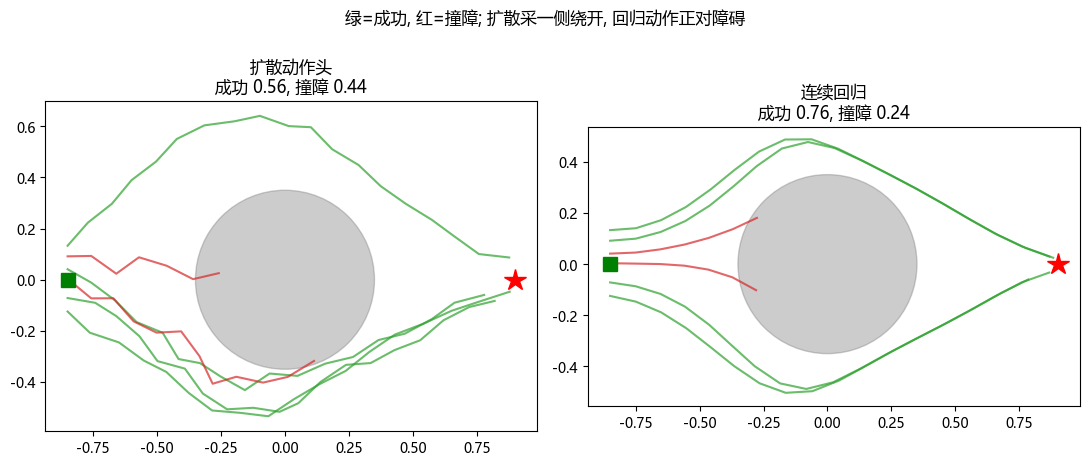

→ 扩散动作头表达多峰=能绕; 回归取平均=直对障碍。这就是 diffusion policy 的价值。


In [5]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1,2,figsize=(11,5))
for ax, (name, fn) in zip(axes, [('扩散动作头', dp.make_diffusion_action_fn(diff, sched)),
                                  ('连续回归', dp.make_regression_action_fn(reg))]):
    for seed in range(6):
        ok,c,steps,tr = dp.rollout(fn, seed=seed, record=True); tr=np.array(tr)
        ax.plot(tr[:,0],tr[:,1],'-',alpha=0.7,color=('C2' if ok else 'C3'))
    circ = plt.Circle((dp.OBST_C[0],dp.OBST_C[1]), dp.OBST_R, color='gray', alpha=0.4); ax.add_patch(circ)
    ax.plot(dp.START_X,0,'gs',ms=10); ax.plot(*dp.GOAL,'r*',ms=16)
    sr,cr = dp.eval_policy(fn, n_episodes=100)
    ax.set_title(f'{name}\n成功 {sr:.2f}, 撞障 {cr:.2f}'); ax.set_aspect('equal')
plt.suptitle('绿=成功, 红=撞障; 扩散采一侧绕开, 回归动作正对障碍'); plt.tight_layout(); plt.show()
print('→ 扩散动作头表达多峰=能绕; 回归取平均=直对障碍。这就是 diffusion policy 的价值。')

## 5. 反思
你看到扩散动作头解决了多峰矛盾。带走:
- **回归取均值**: 多峰的均值落谷里 (直冲障碍) — 数学必然 (L1)。
- **扩散建模分布 + 采样**: 采到某一峰 (上/下绕) → 连续 + 多峰两全。
- 机制 = M13.1 DDPM + state 条件 (同源, L2); 你已会全部。
> 注意: 单步扩散每步独立采样, 可能来回切模式 (抖动) → 这是 N2 action chunking 要治的。
下一步 N2: action chunking 的平滑/反应性权衡。